#1 — Import Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np
!pip install xgboost

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Cross Validation
from sklearn.model_selection import cross_val_score

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


#2 — Load Dataset

In [2]:
df = pd.read_csv("ai_job_impact_dataset.csv")

df.head()

,worker_id,country,continent,year,age,gender,education_level,industry,job_role,years_experience,salary_usd,employment_type,company_size,remote_work,ai_adoption_level,ai_literacy_score,digital_skill_score,productivity_score,hours_worked_per_week,training_hours,reskilling_completed,automation_probability,job_satisfaction,promotion_probability,layoff_probability,employment_status_after_ai,annual_performance_rating,mental_stress_score,innovation_score
0,1,Bangladesh,Asia,2035,36.0,Male,Bachelor,Energy,Energy Auditor,7.0,14288.80,Full-time,Medium,No,90.06,52.64,39.60,64.25,37.7,136.0,No,0.4382,8.01,0.5516,0.1362,Employed,4.16,23.29,46.19
1,2,Denmark,Europe,2035,58.0,Male,Bachelor,Transportation,Aviation Mechanic,13.0,92290.01,Contract,Small,No,81.53,47.79,38.48,46.15,41.6,55.5,Yes,0.4848,8.00,0.4824,0.2122,Employed,3.65,19.45,59.25
2,3,Nigeria,Africa,2035,59.0,Female,High School,IT,DevOps Engineer,34.0,12359.08,Full-time,Large,No,100.00,3.49,7.28,38.16,42.3,110.8,No,0.4564,6.11,0.3561,0.1431,Employed,3.42,47.87,16.69
3,4,Vietnam,Asia,2035,54.0,Female,Bachelor,Manufacturing,Production Supervisor,21.0,15811.44,Full-time,Large,No,97.83,44.29,40.89,76.66,40.0,109.7,Yes,0.6871,5.64,0.3547,0.2724,Employed,3.77,38.92,39.84
4,5,Mexico,North America,2034,54.0,Female,Bachelor,Retail,Inventory Manager,13.0,9951.72,Contract,Small,No,74.58,47.25,39.41,64.97,31.3,71.3,Yes,0.3714,9.68,0.4796,0.1333,Employed,3.79,27.33,47.53


#3 — Data Understanding

In [3]:
# Dataset Shape
print(f"Dataset Shape : {df.shape}")

Dataset Shape : (100000, 29)


In [4]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   worker_id                   100000 non-null  int64  
 1   country                     100000 non-null  object 
 2   continent                   97908 non-null   object 
 3   year                        100000 non-null  int64  
 4   age                         97973 non-null   float64
 5   gender                      97996 non-null   object 
 6   education_level             97999 non-null   object 
 7   industry                    98006 non-null   object 
 8   job_role                    97949 non-null   object 
 9   years_experience            97977 non-null   float64
 10  salary_usd                  97965 non-null   float64
 11  employment_type             97983 non-null   object 
 12  company_size                98012 non-null   object 
 13  remote_work    

In [5]:
# Statistical Summary
display(df.describe())

,worker_id,year,age,years_experience,salary_usd,ai_adoption_level,ai_literacy_score,digital_skill_score,productivity_score,hours_worked_per_week,training_hours,automation_probability,job_satisfaction,promotion_probability,layoff_probability,annual_performance_rating,mental_stress_score,innovation_score
count,100000.000000,100000.000000,97973.000000,97977.000000,97965.000000,97998.000000,97989.000000,98106.000000,97965.000000,97964.000000,98068.000000,98042.000000,98052.000000,98025.000000,98036.000000,98059.000000,97990.000000,97999.000000
mean,50003.747580,2027.486270,41.450655,10.348714,53476.163239,71.926492,45.663136,37.567071,52.064336,39.889859,80.504905,0.369497,7.114112,0.426237,0.133217,3.081087,28.728079,45.115835
std,28859.224175,4.605022,13.868108,8.886407,53896.939841,21.098684,21.016159,18.539245,16.141847,8.871282,30.737865,0.123245,1.141833,0.102881,0.106129,0.863304,9.753149,20.599814
min,1.000000,2020.000000,18.000000,0.000000,1500.000000,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000,2.430000,0.040000,0.000000,1.000000,0.000000,0.000000
25%,25029.750000,2023.000000,29.000000,3.000000,13543.990000,56.890000,29.110000,23.750000,40.910000,36.100000,58.600000,0.286700,6.340000,0.355100,0.040475,2.490000,22.030000,30.300000
50%,49985.500000,2027.000000,41.000000,8.000000,32782.070000,73.140000,45.210000,37.090000,51.870000,41.700000,80.900000,0.370000,7.120000,0.425300,0.123400,3.080000,28.560000,44.520000
75%,74994.250000,2031.000000,53.000000,16.000000,77536.110000,90.120000,61.420000,50.810000,63.190000,45.900000,102.800000,0.448700,7.890000,0.496800,0.206200,3.680000,35.260000,59.200000
max,100000.000000,2035.000000,65.000000,46.000000,497176.080000,100.000000,100.000000,100.000000,100.000000,64.100000,190.100000,0.860300,10.000000,0.827300,0.619100,5.000000,76.880000,100.000000


In [6]:
# Statistical Summary for Categorical Features
display(df.describe(include="object"))

,country,continent,gender,education_level,industry,job_role,employment_type,company_size,remote_work,reskilling_completed,employment_status_after_ai
count,100000,97908,97996,97999,98006,97949,97983,98012,98074,97971,97993
unique,52,6,3,5,15,298,4,4,2,2,4
top,India,Asia,Female,Bachelor,IT,Network Engineer,Full-time,Medium,No,No,Employed
freq,6437,39320,48174,33464,11156,714,68150,27059,64270,57457,85571


In [7]:
# Missing Values Report

missing_values = pd.DataFrame({

    "Missing Values": df.isnull().sum(),

    "Percentage": round(df.isnull().mean()*100,2)

})

missing_values = missing_values[missing_values["Missing Values"]>0]

missing_values.sort_values(by="Percentage",ascending=False)

,Missing Values,Percentage
continent,2092,2.09
job_role,2051,2.05
salary_usd,2035,2.04
hours_worked_per_week,2036,2.04
productivity_score,2035,2.04
reskilling_completed,2029,2.03
age,2027,2.03
years_experience,2023,2.02
employment_type,2017,2.02
ai_literacy_score,2011,2.01


In [8]:
# Handle Missing Values

# Numerical Columns
num_cols = df.select_dtypes(include=["int64","float64"]).columns

# Categorical Columns
cat_cols = df.select_dtypes(include=["object"]).columns

# Fill Numerical Missing Values with Median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill Categorical Missing Values with Mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing Values Handled Successfully.")

Missing Values Handled Successfully.


In [9]:
# Check Missing Values Again

df.isnull().sum().sort_values(ascending=False)

worker_id                     0
ai_literacy_score             0
mental_stress_score           0
annual_performance_rating     0
employment_status_after_ai    0
layoff_probability            0
promotion_probability         0
job_satisfaction              0
automation_probability        0
reskilling_completed          0
training_hours                0
hours_worked_per_week         0
productivity_score            0
digital_skill_score           0
ai_adoption_level             0
country                       0
remote_work                   0
company_size                  0
employment_type               0
salary_usd                    0
years_experience              0
job_role                      0
industry                      0
education_level               0
gender                        0
age                           0
year                          0
continent                     0
innovation_score              0
dtype: int64

In [10]:
#Check Duplicate
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 499


In [11]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Check again
print(f"Dataset Shape After Removing Duplicates: {df.shape}")

Dataset Shape After Removing Duplicates: (99501, 29)


#Check Target Variable
احنا لازم نعرف
هل Target Balanced
ولا
Imbalanced

In [12]:
# Target Distribution
target = df["employment_status_after_ai"].value_counts()

print(target)

print("="*60)

print(df["employment_status_after_ai"].value_counts(normalize=True)*100)

employment_status_after_ai
Employed         87141
Reskilled         7394
Career Change     3669
Unemployed        1297
Name: count, dtype: int64
employment_status_after_ai
Employed         87.578014
Reskilled         7.431081
Career Change     3.687400
Unemployed        1.303504
Name: proportion, dtype: float64


#Cleaning

In [13]:
# Drop Worker ID
df.drop("worker_id", axis=1, inplace=True)

In [14]:
# Separate Numerical and Categorical Columns

numerical_columns = df.select_dtypes(include=["int64","float64"]).columns.tolist()

categorical_columns = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features")
print(numerical_columns)

print("="*80)

print("Categorical Features")
print(categorical_columns)

Numerical Features
['year', 'age', 'years_experience', 'salary_usd', 'ai_adoption_level', 'ai_literacy_score', 'digital_skill_score', 'productivity_score', 'hours_worked_per_week', 'training_hours', 'automation_probability', 'job_satisfaction', 'promotion_probability', 'layoff_probability', 'annual_performance_rating', 'mental_stress_score', 'innovation_score']
Categorical Features
['country', 'continent', 'gender', 'education_level', 'industry', 'job_role', 'employment_type', 'company_size', 'remote_work', 'reskilling_completed', 'employment_status_after_ai']


#Exploratory Data Analysis (EDA)


علشان نشوف توزيع الـ Target.


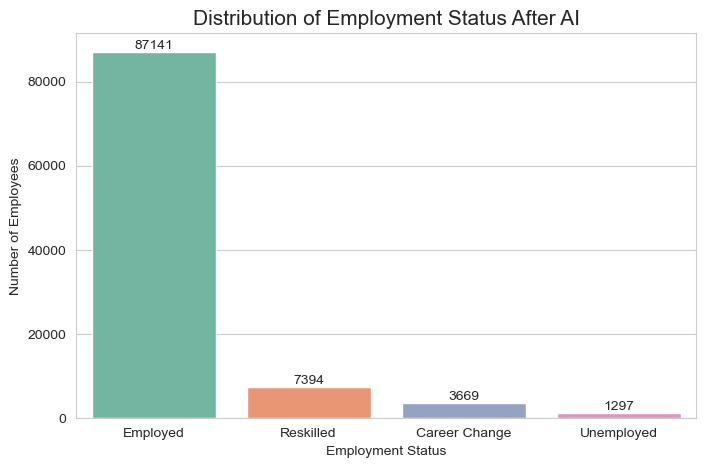

In [15]:
# Target Variable Distribution

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="employment_status_after_ai",
    palette="Set2",
    order=df["employment_status_after_ai"].value_counts().index
)

plt.title("Distribution of Employment Status After AI", fontsize=15)
plt.xlabel("Employment Status")
plt.ylabel("Number of Employees")

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

معرفة توزيع الذكور والإناث داخل البيانات.

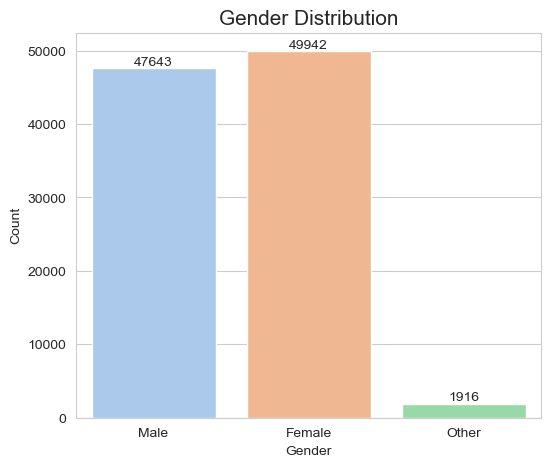

In [16]:
# Gender Distribution

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="gender",
    palette="pastel"
)

plt.title("Gender Distribution", fontsize=15)
plt.xlabel("Gender")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

عشان نعرف اي اكتر مؤهل موجود

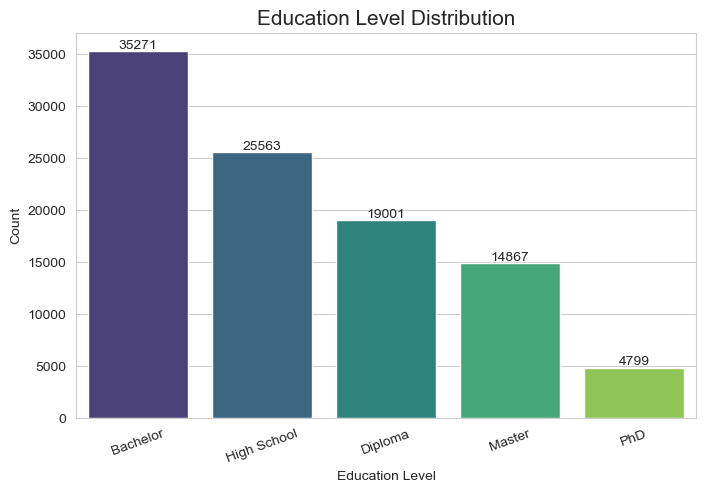

In [17]:
# Education Level Distribution

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="education_level",
    order=df["education_level"].value_counts().index,
    palette="viridis"
)

plt.title("Education Level Distribution", fontsize=15)
plt.xlabel("Education Level")
plt.ylabel("Count")

plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

بنشوف أكتر الصناعات انتشارًا.

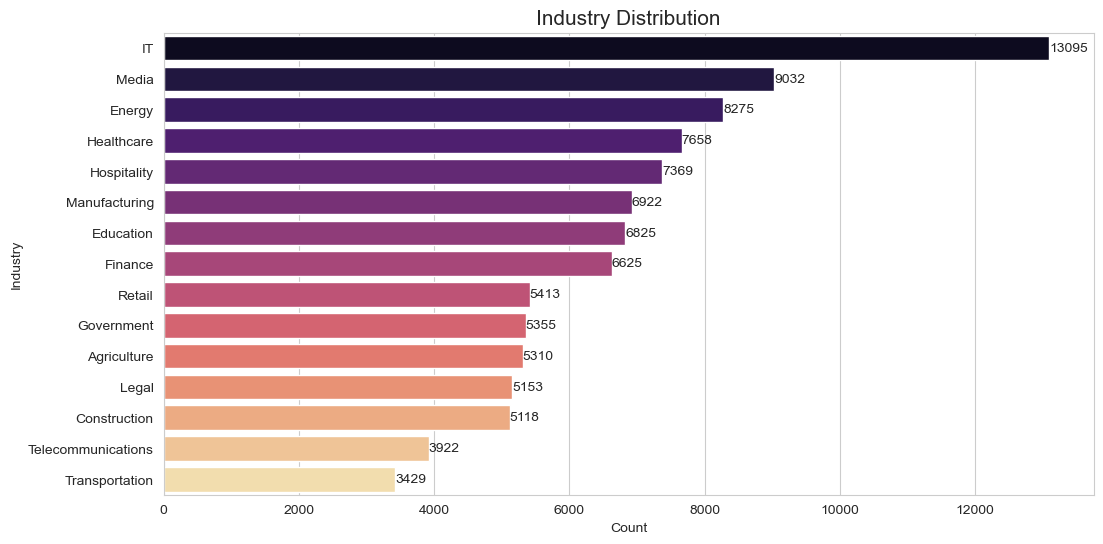

In [18]:
# Industry Distribution

plt.figure(figsize=(12,6))

ax = sns.countplot(
    data=df,
    y="industry",
    order=df["industry"].value_counts().index,
    palette="magma"
)

plt.title("Industry Distribution", fontsize=15)
plt.xlabel("Count")
plt.ylabel("Industry")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

عندنا 298 وظيفة.
اخترنا أعلى 15 وظيفة.

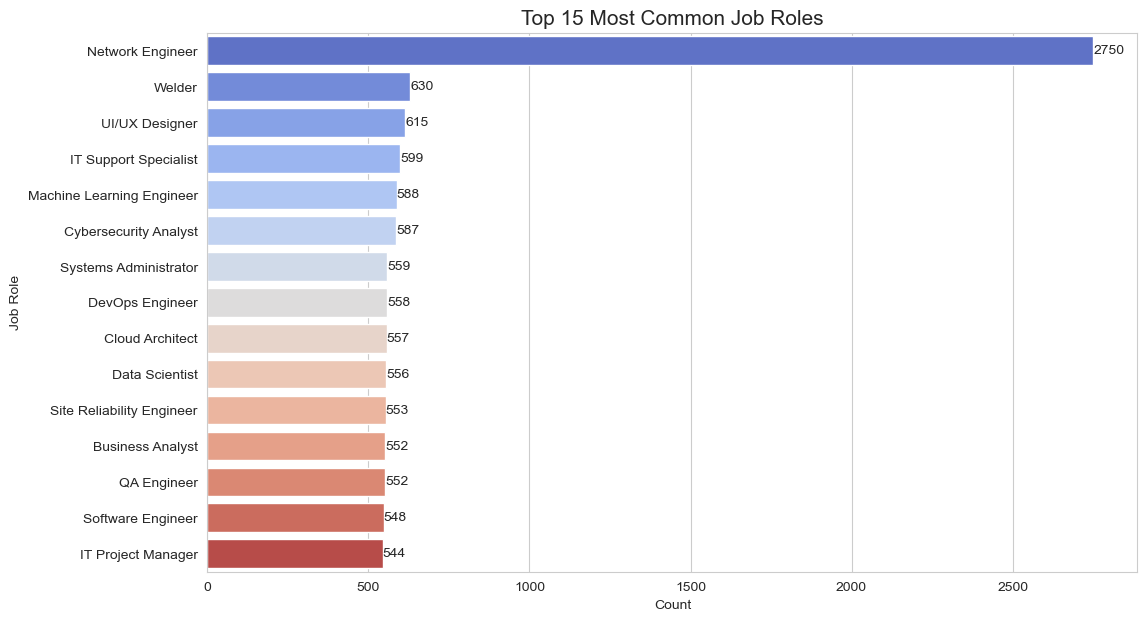

In [19]:
# Top 15 Job Roles

top_jobs = df["job_role"].value_counts().head(15)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index,
    palette="coolwarm"
)

plt.title("Top 15 Most Common Job Roles", fontsize=15)
plt.xlabel("Count")
plt.ylabel("Job Role")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

أكثر الدول الموجودة.

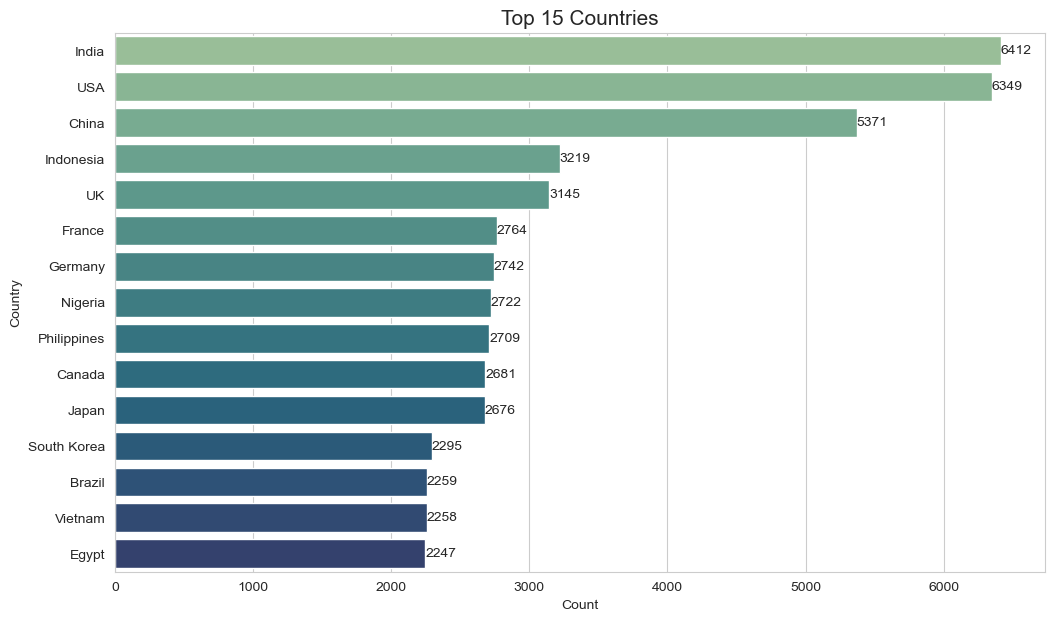

In [20]:
# Top 15 Countries

top_countries = df["country"].value_counts().head(15)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette="crest"
)

plt.title("Top 15 Countries", fontsize=15)
plt.xlabel("Count")
plt.ylabel("Country")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

هل مستوى التعليم يؤثر على الحالة الوظيفية بعد الذكاء الاصطناعي؟

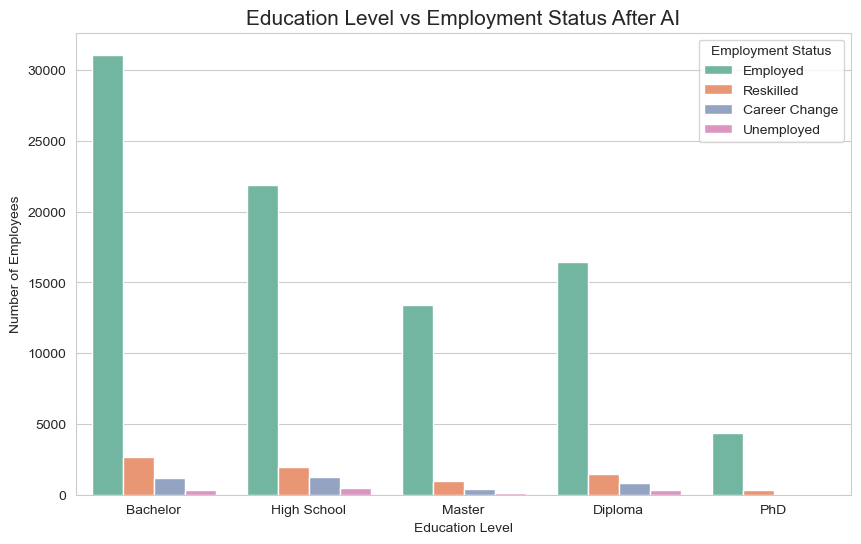

In [21]:
# Education Level vs Employment Status

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="education_level",
    hue="employment_status_after_ai",
    palette="Set2"
)

plt.title("Education Level vs Employment Status After AI", fontsize=15)
plt.xlabel("Education Level")
plt.ylabel("Number of Employees")

plt.legend(title="Employment Status")

plt.show()

هل الشركات الكبيرة بتحتفظ بالموظفين أكثر

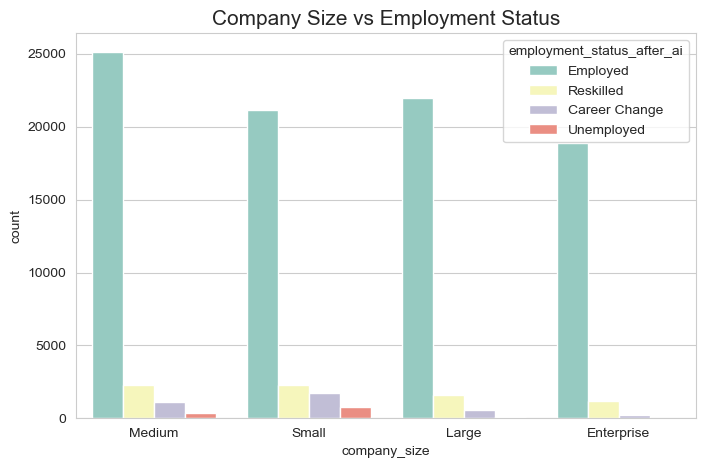

In [22]:
# Company Size vs Employment Status

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="company_size",
    hue="employment_status_after_ai",
    palette="Set3"
)

plt.title("Company Size vs Employment Status", fontsize=15)

plt.show()

هل العمل عن بعد

قلل

أثر الذكاء الاصطناعى؟

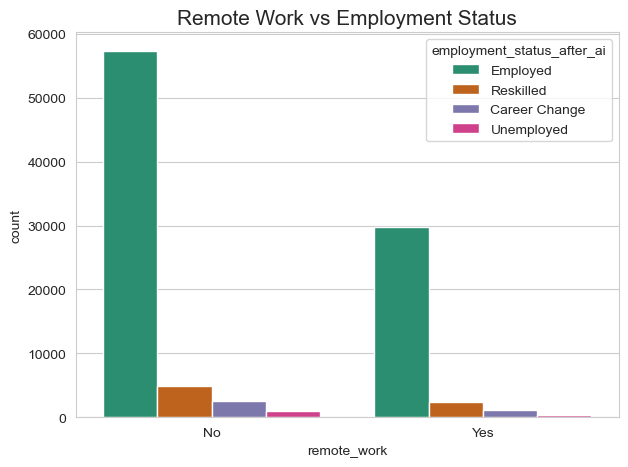

In [23]:
# Remote Work vs Employment Status

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="remote_work",
    hue="employment_status_after_ai",
    palette="Dark2"
)

plt.title("Remote Work vs Employment Status", fontsize=15)

plt.show()

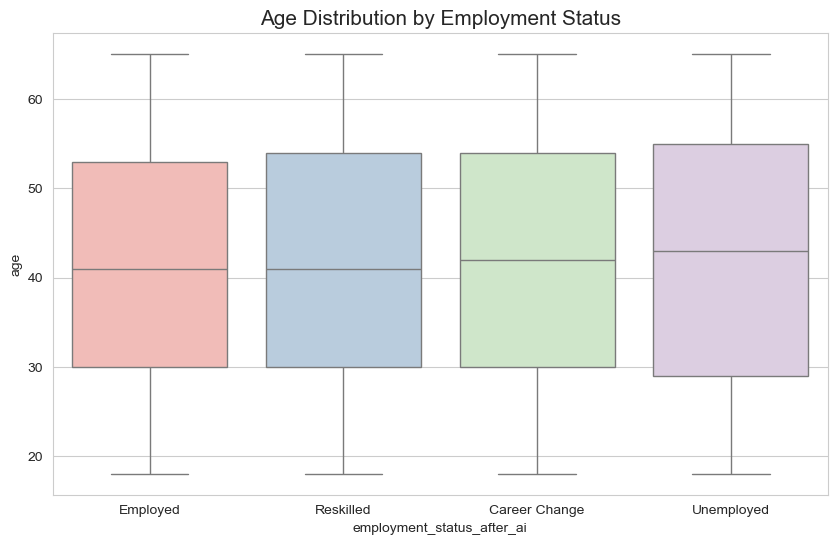

In [24]:
# Age vs Employment Status

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="employment_status_after_ai",
    y="age",
    palette="Pastel1"
)

plt.title("Age Distribution by Employment Status", fontsize=15)

plt.show()

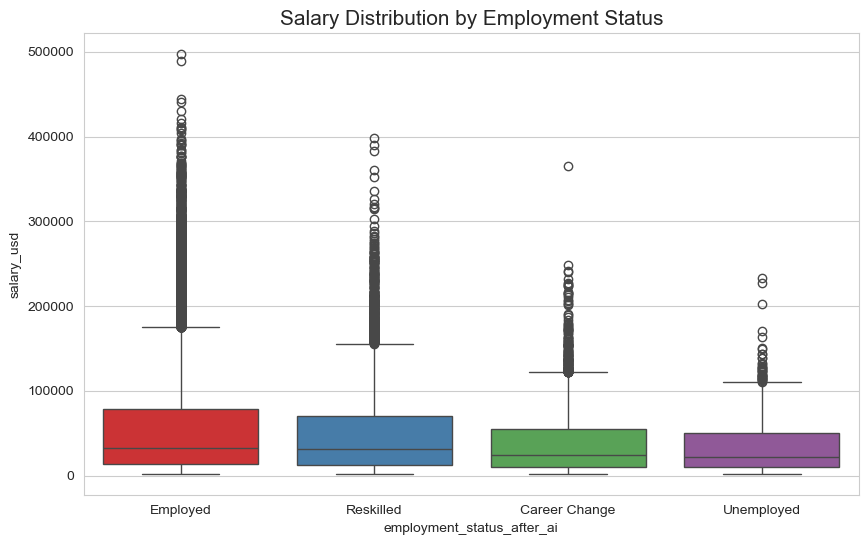

In [25]:
# Salary vs Employment Status

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="employment_status_after_ai",
    y="salary_usd",
    palette="Set1"
)

plt.title("Salary Distribution by Employment Status", fontsize=15)

plt.show()

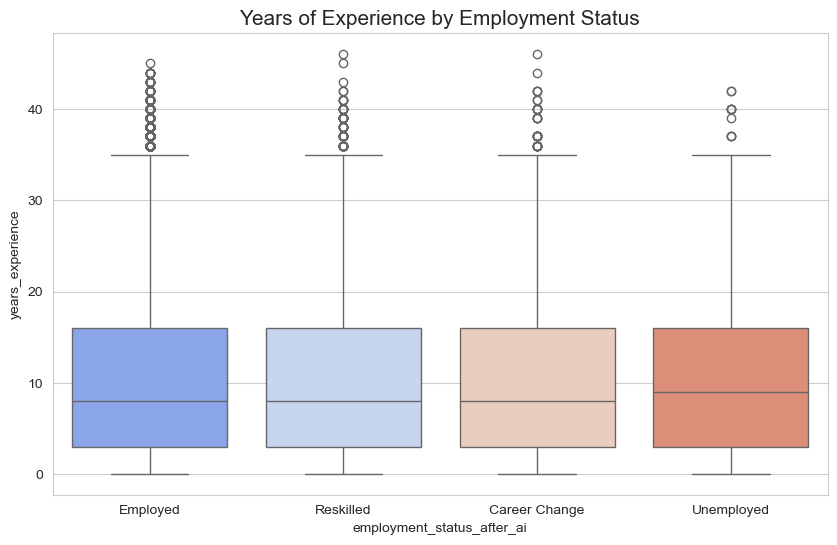

In [26]:
# Experience vs Employment Status

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="employment_status_after_ai",
    y="years_experience",
    palette="coolwarm"
)

plt.title("Years of Experience by Employment Status", fontsize=15)

plt.show()

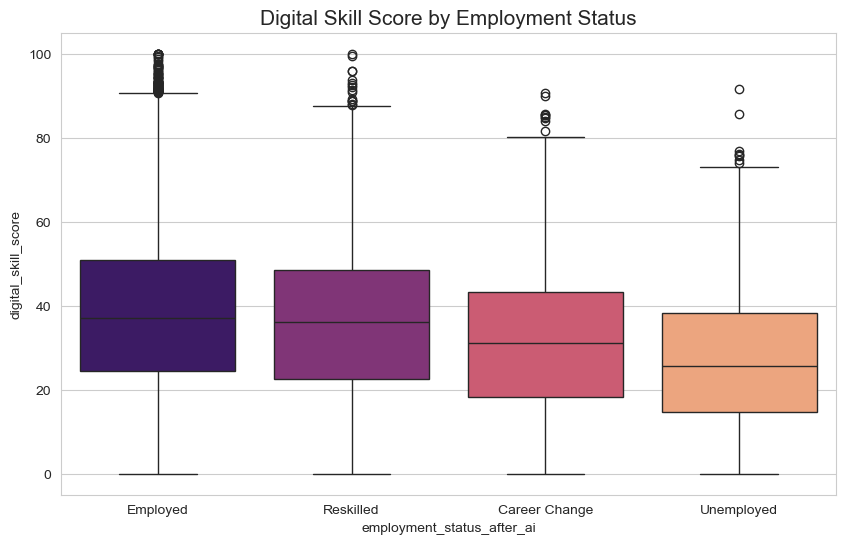

In [27]:
# Digital Skill Score

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="employment_status_after_ai",
    y="digital_skill_score",
    palette="magma"
)

plt.title("Digital Skill Score by Employment Status", fontsize=15)

plt.show()

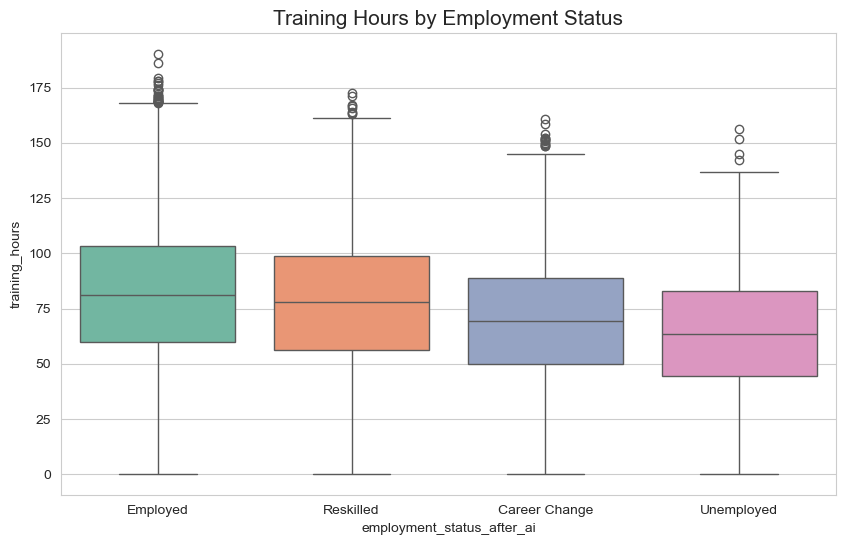

In [28]:
# Training Hours

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="employment_status_after_ai",
    y="training_hours",
    palette="Set2"
)

plt.title("Training Hours by Employment Status", fontsize=15)

plt.show()

# Correlation Heatmap

الهدف: معرفة العلاقة بين الأعمدة الرقمية، وهل فيه أعمدة مرتبطة ببعض بقوة

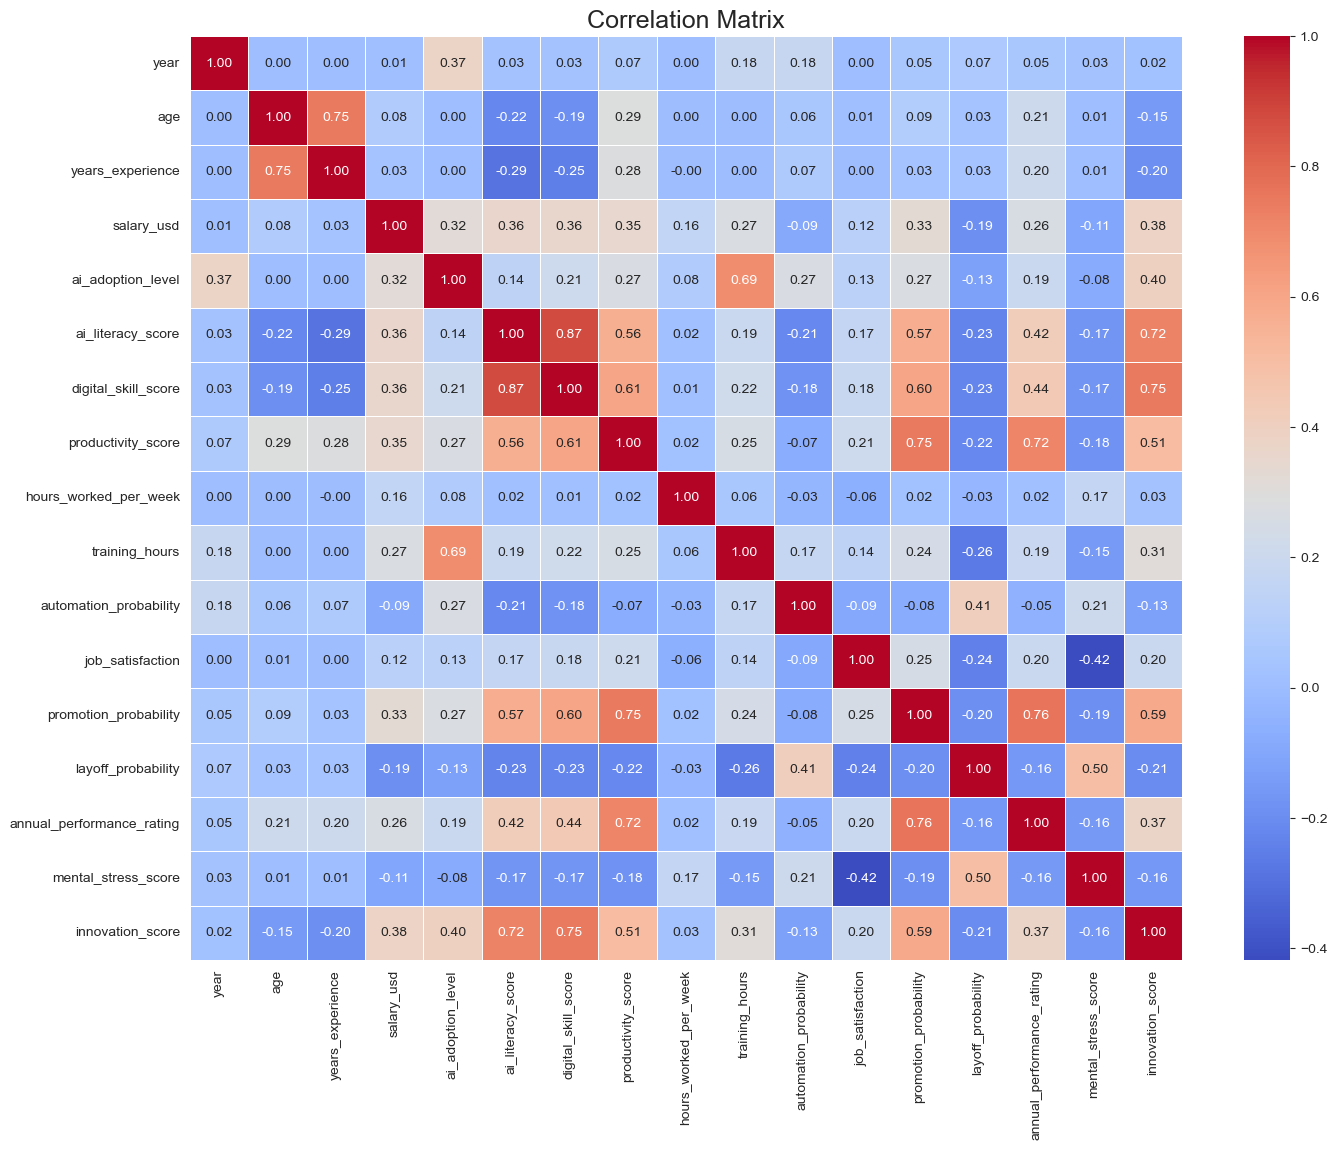

In [29]:
# Correlation Heatmap

plt.figure(figsize=(16,12))

corr = df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix", fontsize=18)

plt.show()

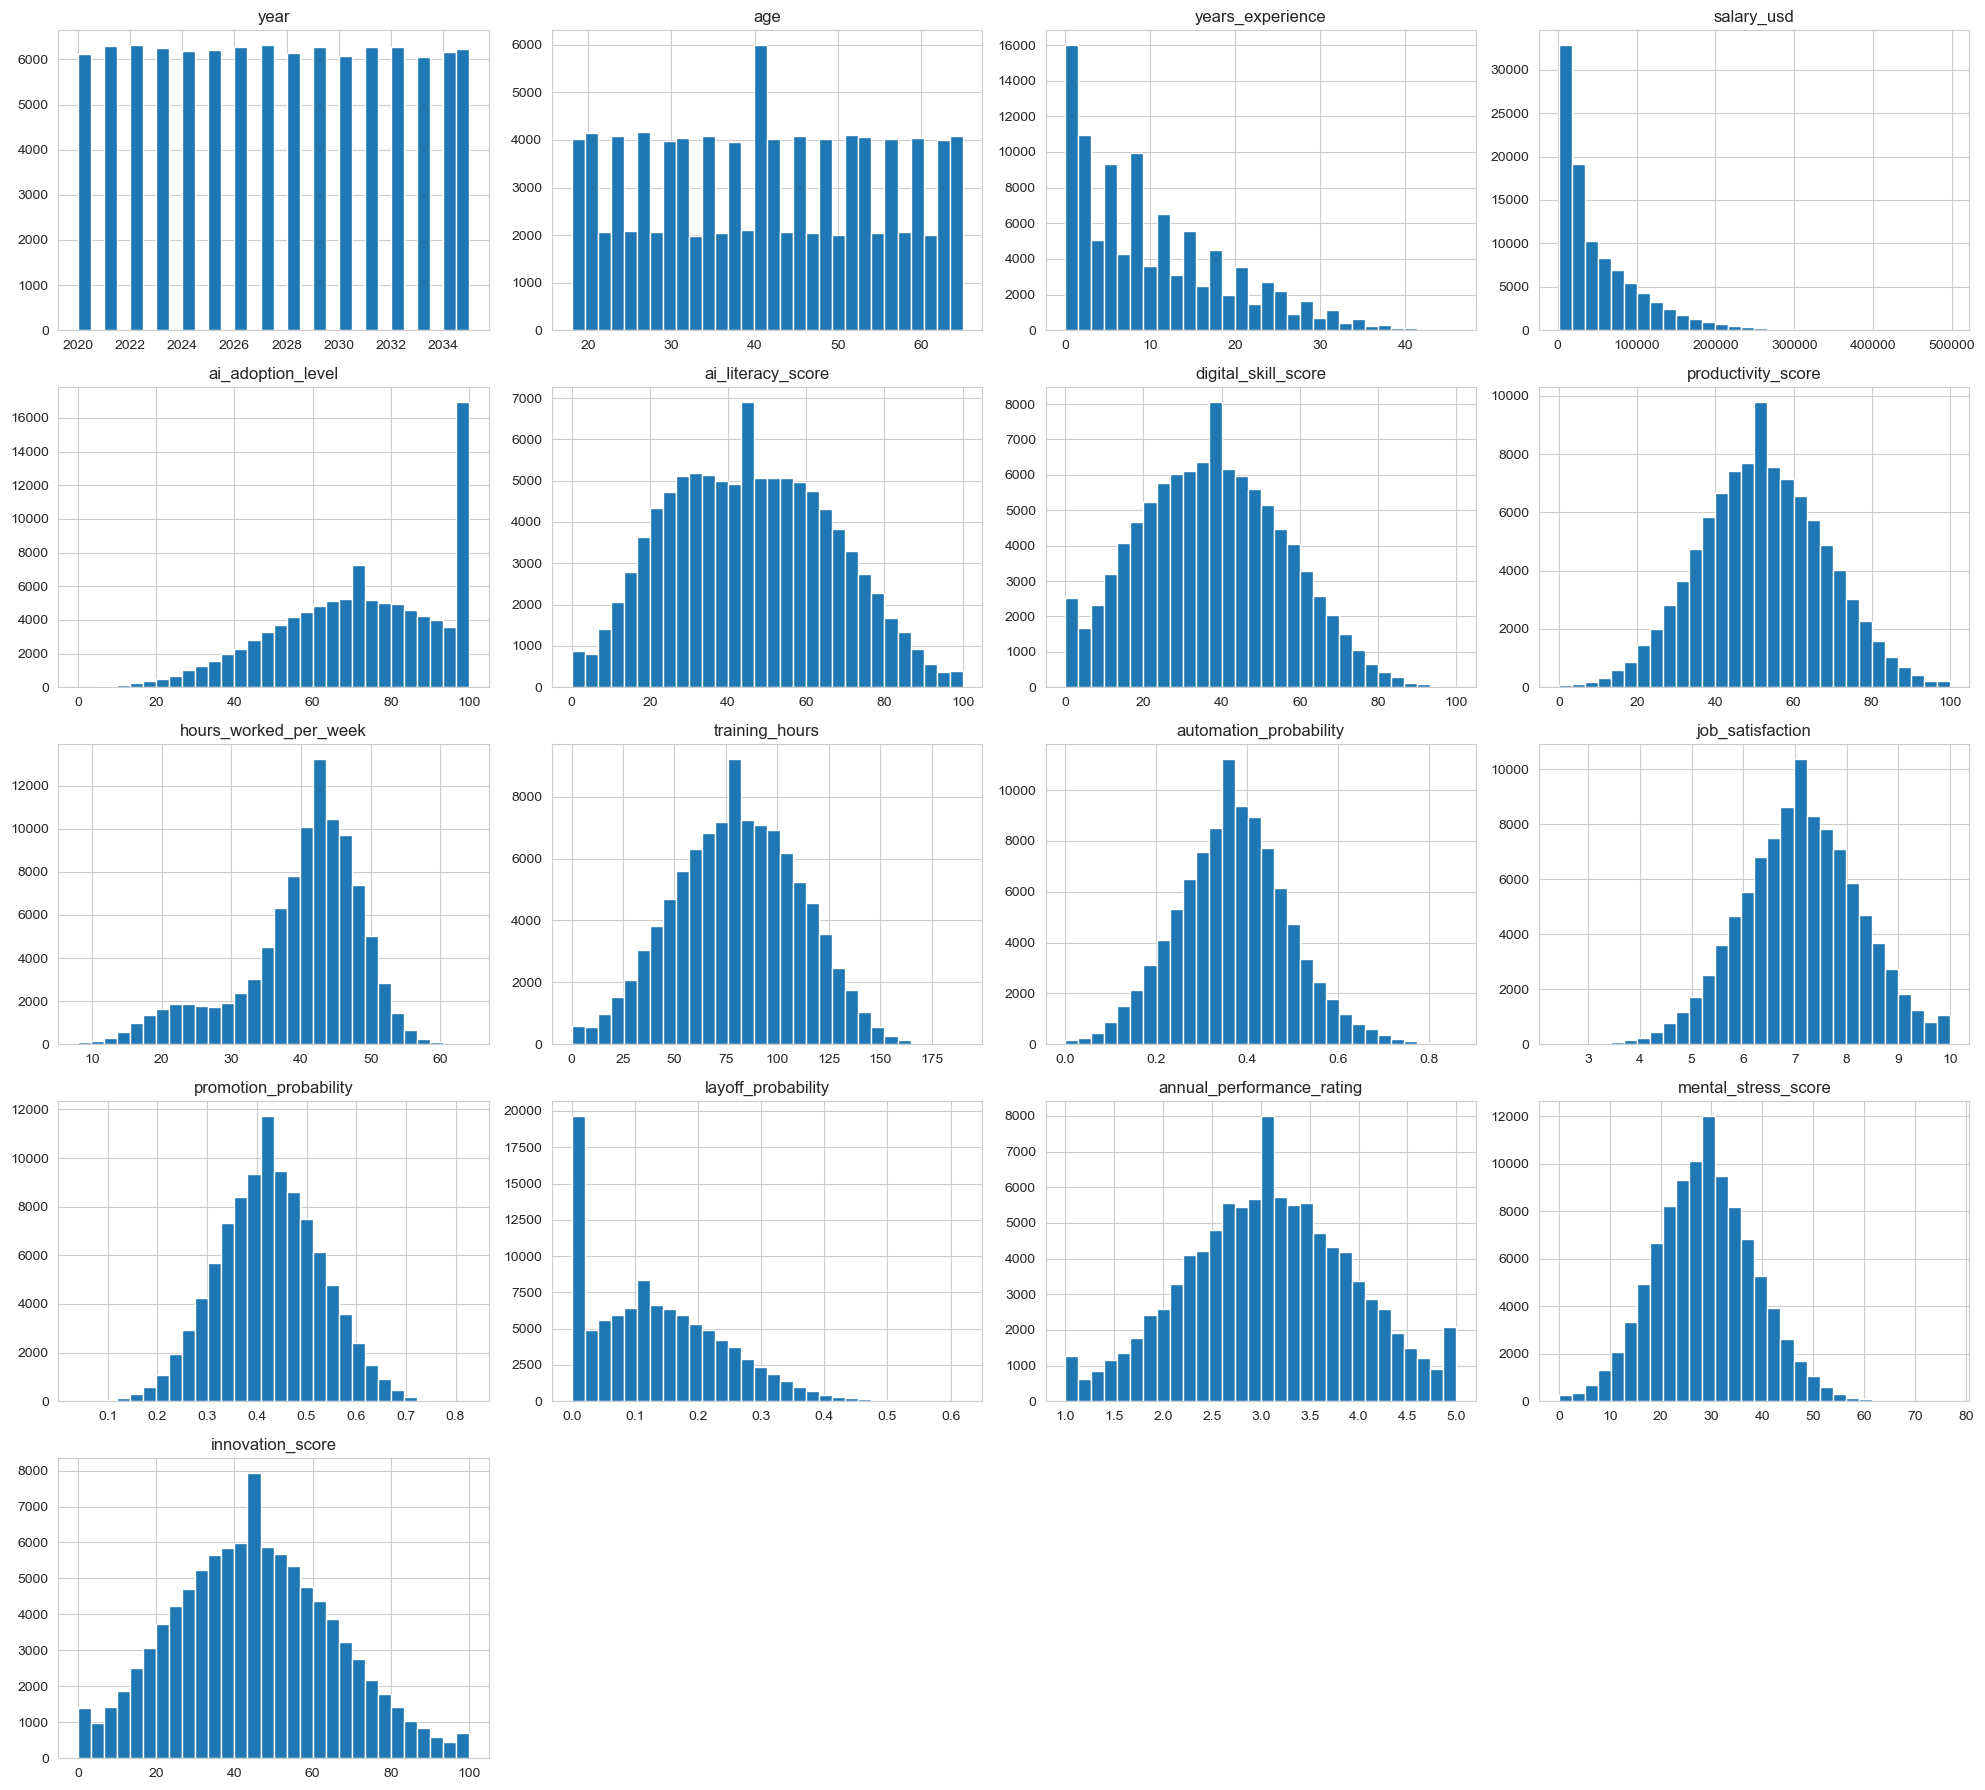

In [30]:
# Distribution of Numerical Features

num_cols = df.select_dtypes(include=["int64","float64"]).columns

df[num_cols].hist(
    figsize=(20,18),
    bins=30
)

plt.tight_layout()

plt.show()

#Outliers Detection

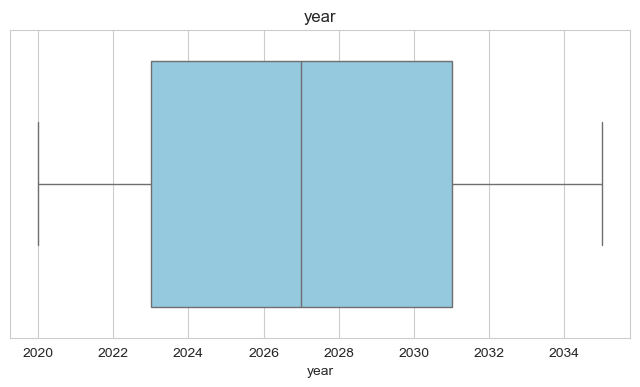

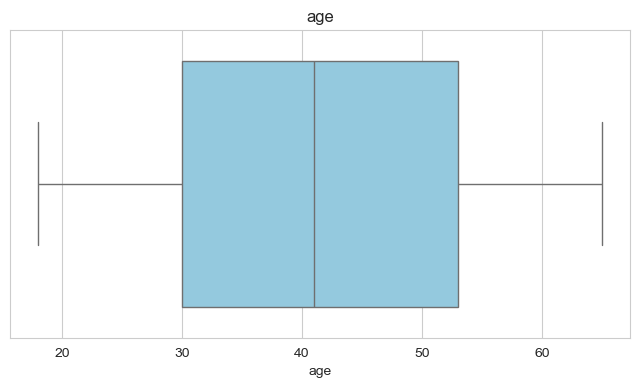

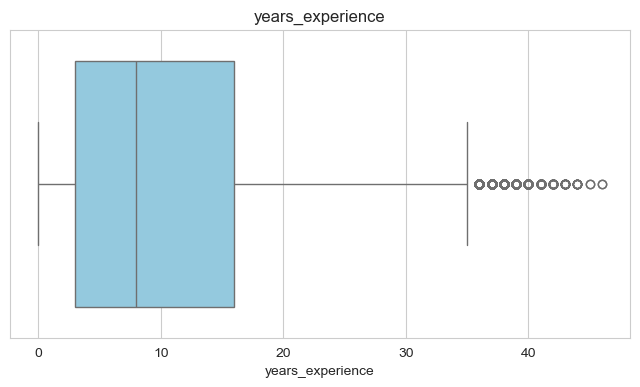

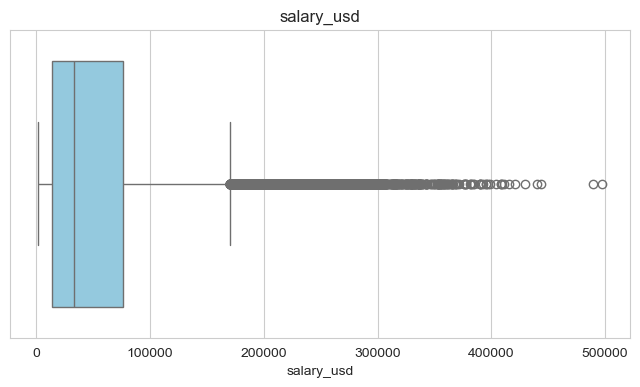

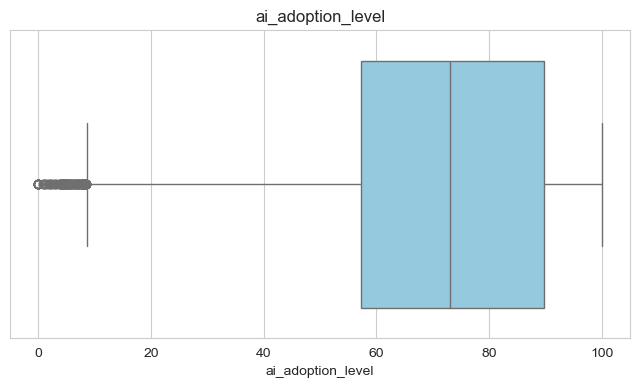

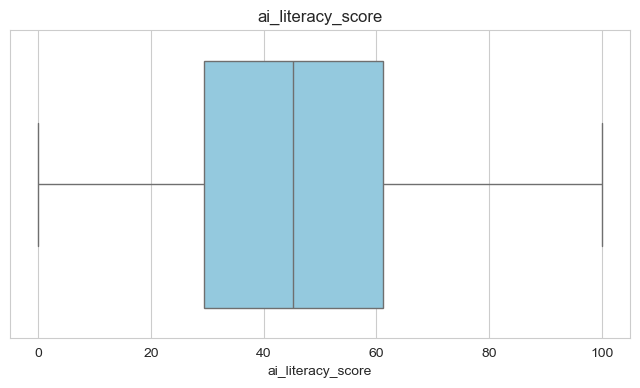

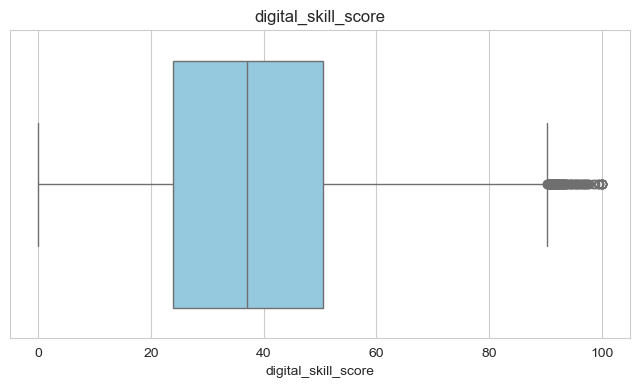

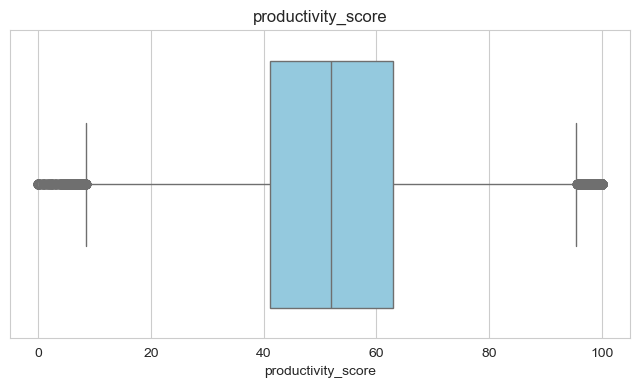

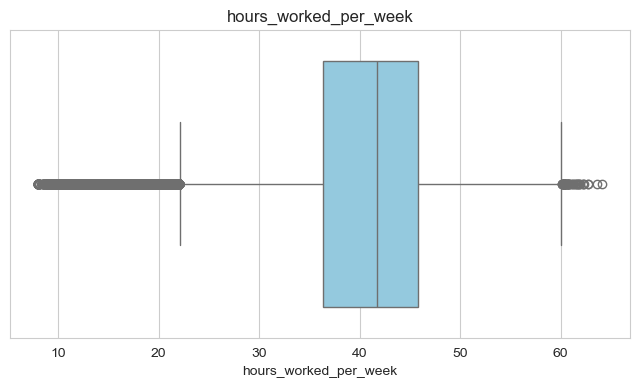

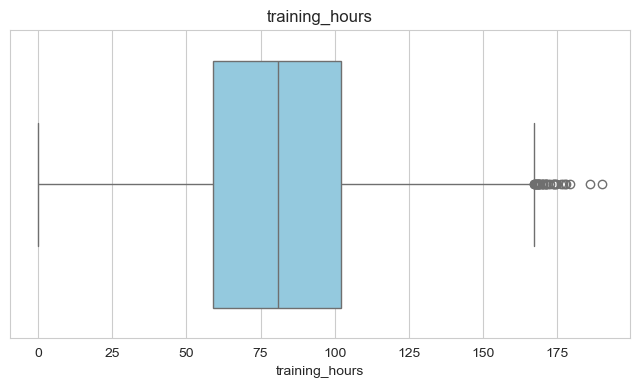

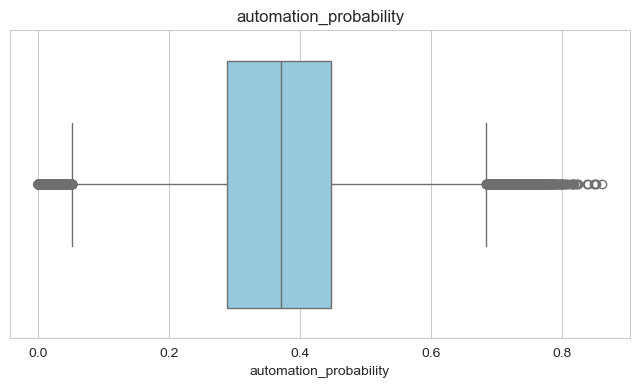

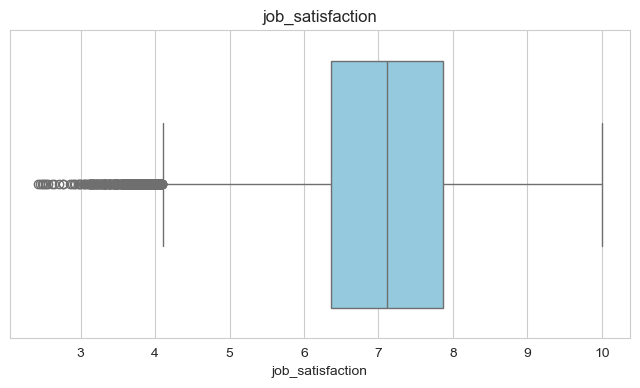

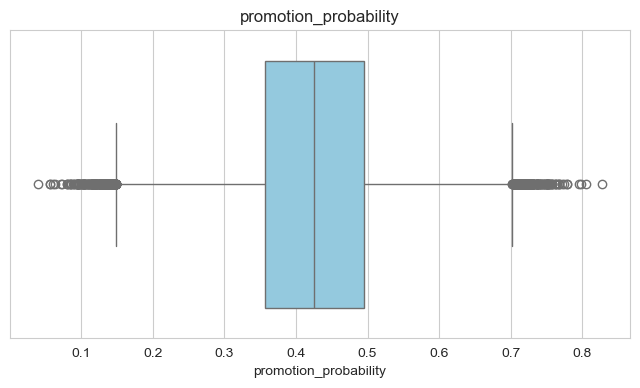

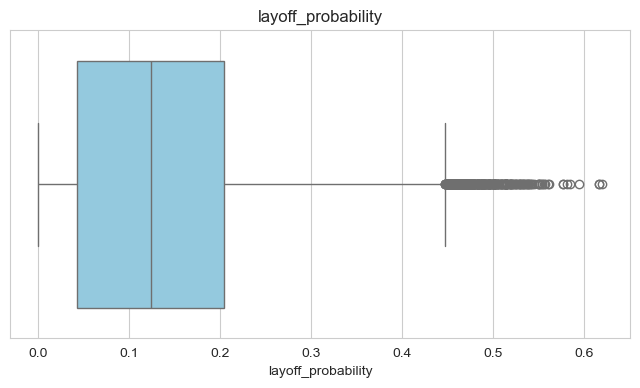

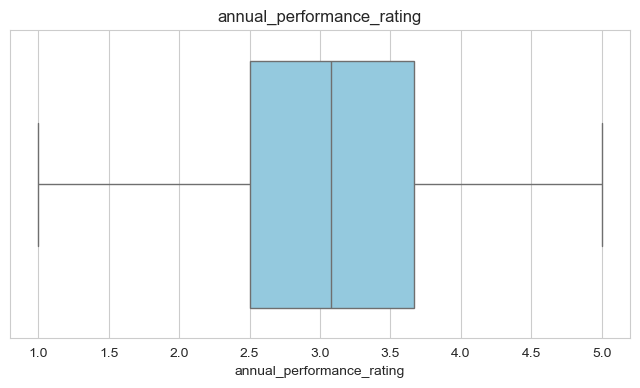

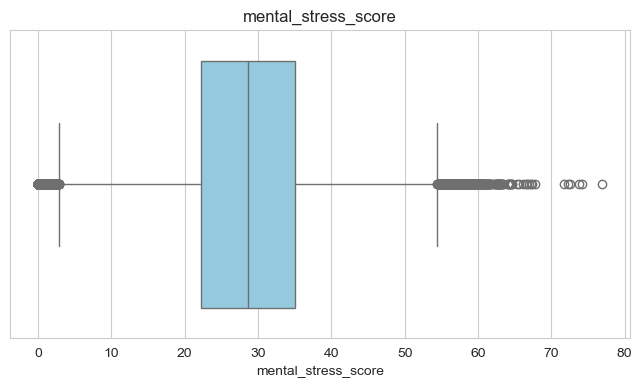

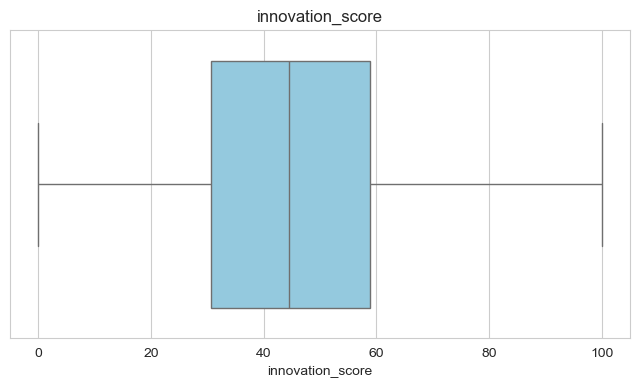

In [31]:
# Boxplots for Numerical Features

num_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col],
        color="skyblue"
    )

    plt.title(col)

    plt.show()

هنا بنحسب كل Feature

قد إيه مهم بالنسبة للـ Target وده بيساعدنا نعرف مين أهم الأعمدة.

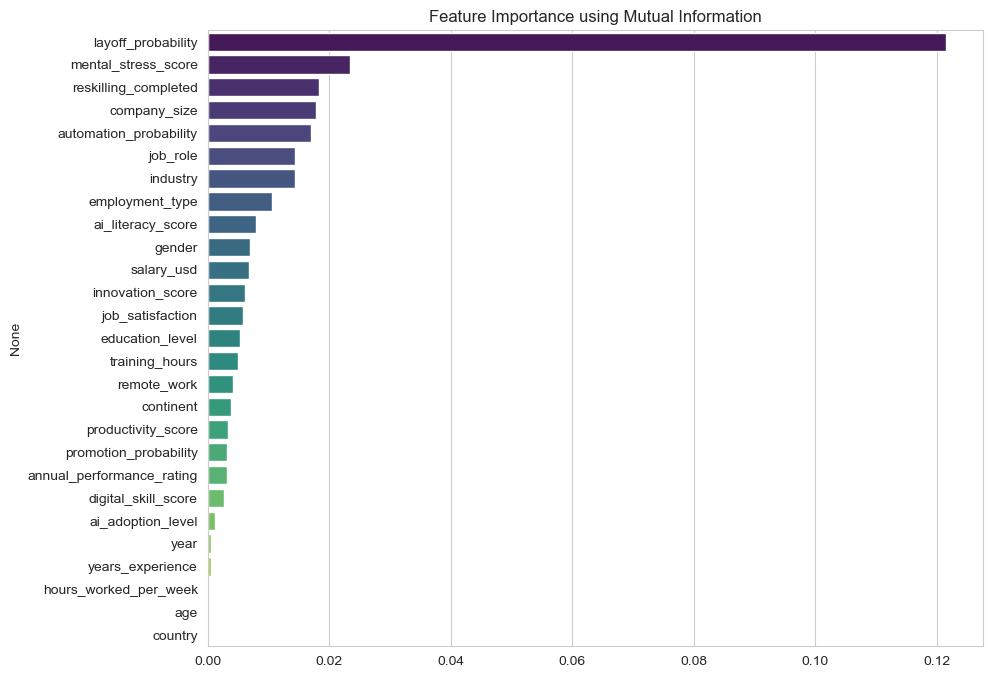

In [32]:
# Feature Importance using Mutual Information

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

# Copy dataset
df_mi = df.copy()

# Encode categorical columns
le = LabelEncoder()

for col in df_mi.select_dtypes(include="object").columns:
    df_mi[col] = le.fit_transform(df_mi[col])

# Features & Target
X = df_mi.drop("employment_status_after_ai", axis=1)
y = df_mi["employment_status_after_ai"]

# Calculate MI
mi = mutual_info_classif(X, y)

mi_scores = pd.Series(mi, index=X.columns)

mi_scores = mi_scores.sort_values(ascending=False)

plt.figure(figsize=(10,8))

sns.barplot(
    x=mi_scores.values,
    y=mi_scores.index,
    palette="viridis"
)

plt.title("Feature Importance using Mutual Information")

plt.show()

In [33]:
# Employment Status Percentage

status = (
    df["employment_status_after_ai"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

status

employment_status_after_ai
Employed         87.58
Reskilled         7.43
Career Change     3.69
Unemployed        1.30
Name: proportion, dtype: float64

#Prepare Data

In [34]:
# Features & Target

selected_features = [
    "age",
    "years_experience",
    "salary_usd",
    "ai_literacy_score",
    "digital_skill_score",
    "automation_probability",
    "mental_stress_score",
    "industry",
    "country",
    "reskilling_completed"
]

X = df[selected_features]
y = df["employment_status_after_ai"]

print(X.head())
print(X.shape)

    age  years_experience  salary_usd  ai_literacy_score  digital_skill_score  \
0  36.0               7.0    14288.80              52.64                39.60   
1  58.0              13.0    92290.01              47.79                38.48   
2  59.0              34.0    12359.08               3.49                 7.28   
3  54.0              21.0    15811.44              44.29                40.89   
4  54.0              13.0     9951.72              47.25                39.41   

   automation_probability  mental_stress_score        industry     country  \
0                  0.4382                23.29          Energy  Bangladesh   
1                  0.4848                19.45  Transportation     Denmark   
2                  0.4564                47.87              IT     Nigeria   
3                  0.6871                38.92   Manufacturing     Vietnam   
4                  0.3714                27.33          Retail      Mexico   

  reskilling_completed  
0                  

In [35]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set : (79600, 10)
Testing Set : (19901, 10)


#Encoding Features
One-Hot Encoding للأعمدة النصية.

In [36]:
# One-Hot Encoding

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (79600, 73)
Testing Shape : (19901, 73)


In [37]:
# Label Encoding Target

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print(label_encoder.classes_)

['Career Change' 'Employed' 'Reskilled' 'Unemployed']


In [38]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


In [39]:
X_train = X_train.astype(int)
X_test = X_test.astype(int)

In [40]:
X_train.head()

,age,years_experience,salary_usd,ai_literacy_score,digital_skill_score,automation_probability,mental_stress_score,industry_Construction,industry_Education,industry_Energy,industry_Finance,industry_Government,industry_Healthcare,industry_Hospitality,industry_IT,industry_Legal,industry_Manufacturing,industry_Media,industry_Retail,industry_Telecommunications,industry_Transportation,country_Australia,country_Austria,country_Bangladesh,country_Belgium,country_Brazil,country_Canada,country_Chile,country_China,country_Colombia,country_Czech Republic,country_Denmark,country_Egypt,country_Finland,country_France,country_Germany,country_Ghana,country_Greece,country_Hungary,country_India,country_Indonesia,country_Ireland,country_Israel,country_Italy,country_Japan,country_Kenya,country_Malaysia,country_Mexico,country_Morocco,country_Netherlands,country_New Zealand,country_Nigeria,country_Norway,country_Pakistan,country_Peru,country_Philippines,country_Poland,country_Portugal,country_Romania,country_Saudi Arabia,country_Singapore,country_South Africa,country_South Korea,country_Spain,country_Sweden,country_Switzerland,country_Thailand,country_Turkey,country_UAE,country_UK,country_USA,country_Vietnam,reskilling_completed_Yes
13469,21,2,35941,20,8,0,28,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
12803,25,4,10708,17,2,0,37,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
53196,52,10,32782,25,23,0,52,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
58579,50,9,9069,8,9,0,42,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
75659,20,1,11992,48,40,0,30,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


#Build All Models

In [41]:
from sklearn.svm import SVC, LinearSVC
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=500,
        random_state=42,
        n_jobs=-1
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        n_jobs=-1
    ),

    "Support Vector Machine": LinearSVC(
        random_state=42,
        max_iter=3000
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    )

}

In [42]:
# Train & Evaluate Models

import time
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

results = []

scaled_models = {
    "Logistic Regression",
    "K-Nearest Neighbors",
    "Support Vector Machine"
}

# استخدم 30% من بيانات التدريب لتسريع التجربة
X_train_fast, _, y_train_fast, _ = train_test_split(
    X_train,
    y_train,
    train_size=0.3,
    stratify=y_train,
    random_state=42
)

X_train_scaled_fast, _, _, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=0.3,
    stratify=y_train,
    random_state=42
)

for name, model in models.items():

    print("=" * 80)
    print(name)
    print("=" * 80)

    start = time.time()

    try:

        # Models that need Scaling
        if name in scaled_models:

            model.fit(X_train_scaled_fast, y_train_fast)
            y_pred = model.predict(X_test_scaled)

        # Models that don't need Scaling
        else:

            model.fit(X_train_fast, y_train_fast)
            y_pred = model.predict(X_test)

        end = time.time()

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        pre = precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        rec = recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        results.append([
            name,
            round(acc, 4),
            round(pre, 4),
            round(rec, 4),
            round(f1, 4),
            round(end - start, 2)
        ])

        print(classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        ))

        print(f"Accuracy      : {acc:.4f}")
        print(f"Precision     : {pre:.4f}")
        print(f"Recall        : {rec:.4f}")
        print(f"F1 Score      : {f1:.4f}")
        print(f"Training Time : {end-start:.2f} sec")

    except Exception as e:

        print(f"Error in {name}")
        print(e)

    print("=" * 80)

Logistic Regression
               precision    recall  f1-score   support

Career Change       0.23      0.00      0.01       734
     Employed       0.88      1.00      0.93     17429
    Reskilled       0.00      0.00      0.00      1479
   Unemployed       0.25      0.06      0.10       259

     accuracy                           0.87     19901
    macro avg       0.34      0.27      0.26     19901
 weighted avg       0.78      0.87      0.82     19901

Accuracy      : 0.8749
Precision     : 0.7801
Recall        : 0.8749
F1 Score      : 0.8194
Training Time : 3.59 sec
K-Nearest Neighbors
               precision    recall  f1-score   support

Career Change       0.16      0.02      0.04       734
     Employed       0.88      0.98      0.93     17429
    Reskilled       0.09      0.01      0.02      1479
   Unemployed       0.09      0.02      0.03       259

     accuracy                           0.86     19901
    macro avg       0.30      0.26      0.26     19901
 weighted avg

#Train All Models

#Compare Models

In [43]:
# Models Comparison

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (sec)"
    ]
)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,Logistic Regression,0.8749,0.7801,0.8749,0.8194,3.59
1,Naive Bayes,0.8746,0.7709,0.8746,0.8186,0.24
2,Support Vector Machine,0.8758,0.7670,0.8758,0.8178,1.77
3,Random Forest,0.8758,0.7670,0.8758,0.8178,1.31
4,XGBoost,0.8753,0.7687,0.8753,0.8178,2.33
5,K-Nearest Neighbors,0.8634,0.7826,0.8634,0.8162,5.13
6,Decision Tree,0.8364,0.7839,0.8364,0.8077,0.72


#Best Model

In [44]:
# Best Model

best_model = results_df.iloc[0]

print(best_model)

Model                  Logistic Regression
Accuracy                            0.8749
Precision                           0.7801
Recall                              0.8749
F1 Score                            0.8194
Training Time (sec)                   3.59
Name: 0, dtype: object


In [46]:
from imblearn.over_sampling import SMOTE

In [47]:
# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Before SMOTE
print("="*60)
print("Class Distribution Before SMOTE")
print("="*60)

if isinstance(y_train, np.ndarray):
    before = pd.Series(y_train).value_counts().sort_index()
else:
    before = y_train.value_counts().sort_index()

print(before)

# After SMOTE
print("\n")
print("="*60)
print("Class Distribution After SMOTE")
print("="*60)

after = pd.Series(y_train_smote).value_counts().sort_index()

print(after)

# Shapes
print("\n")
print("="*60)
print("Dataset Shapes")
print("="*60)

print("X_train Before :", X_train.shape)
print("y_train Before :", len(y_train))

print("X_train After  :", X_train_smote.shape)
print("y_train After  :", len(y_train_smote))

Class Distribution Before SMOTE
0     2935
1    69712
2     5915
3     1038
Name: count, dtype: int64


Class Distribution After SMOTE
0    69712
1    69712
2    69712
3    69712
Name: count, dtype: int64


Dataset Shapes
X_train Before : (79600, 73)
y_train Before : 79600
X_train After  : (278848, 73)
y_train After  : 278848


In [48]:
# Scaling After SMOTE

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_smote_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

In [49]:
# Train & Evaluate Models After SMOTE

import time
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

results_smote = []

scaled_models = {
    "Logistic Regression",
    "K-Nearest Neighbors",
    "Support Vector Machine"
}

for name, model in models.items():

    print("=" * 80)
    print(name)
    print("=" * 80)

    start = time.time()

    # Models تحتاج Scaling
    if name in scaled_models:

        model.fit(X_train_smote_scaled, y_train_smote)

        y_pred = model.predict(X_test_scaled)

    # Models لا تحتاج Scaling
    else:

        model.fit(X_train_smote, y_train_smote)

        y_pred = model.predict(X_test)

    end = time.time()

    # Metrics

    acc = accuracy_score(y_test, y_pred)

    pre = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results_smote.append([
        name,
        round(acc, 4),
        round(pre, 4),
        round(rec, 4),
        round(f1, 4),
        round(end - start, 2)
    ])

    # Classification Report

    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        zero_division=0
    ))

    print(f"Accuracy      : {acc:.4f}")
    print(f"Precision     : {pre:.4f}")
    print(f"Recall        : {rec:.4f}")
    print(f"F1 Score      : {f1:.4f}")
    print(f"Training Time : {end-start:.2f} sec")

    print("=" * 80)

Logistic Regression
               precision    recall  f1-score   support

Career Change       0.10      0.04      0.06       734
     Employed       0.88      0.94      0.91     17429
    Reskilled       0.07      0.03      0.04      1479
   Unemployed       0.14      0.21      0.17       259

     accuracy                           0.83     19901
    macro avg       0.30      0.31      0.29     19901
 weighted avg       0.78      0.83      0.81     19901

Accuracy      : 0.8323
Precision     : 0.7848
Recall        : 0.8323
F1 Score      : 0.8065
Training Time : 9.29 sec
K-Nearest Neighbors
               precision    recall  f1-score   support

Career Change       0.10      0.06      0.07       734
     Employed       0.88      0.94      0.91     17429
    Reskilled       0.08      0.04      0.05      1479
   Unemployed       0.08      0.07      0.08       259

     accuracy                           0.83     19901
    macro avg       0.29      0.28      0.28     19901
 weighted avg

In [50]:
# Results After SMOTE

results_smote_df = pd.DataFrame(
    results_smote,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (sec)"
    ]
)

results_smote_df = results_smote_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

results_smote_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
0,Support Vector Machine,0.8522,0.7821,0.8522,0.8130,16.76
1,Logistic Regression,0.8323,0.7848,0.8323,0.8065,9.29
2,K-Nearest Neighbors,0.8291,0.7829,0.8291,0.8044,24.84
3,Random Forest,0.8158,0.7888,0.8158,0.7998,20.96
4,XGBoost,0.8020,0.7882,0.8020,0.7930,15.75
5,Decision Tree,0.7594,0.7892,0.7594,0.7731,9.19
6,Naive Bayes,0.2973,0.8169,0.2973,0.4019,0.88


هنعمل مقارنة بين قبل وبعد SMOTE

In [51]:
comparison = results_df.merge(
    results_smote_df,
    on="Model",
    suffixes=("_Before", "_After")
)

comparison

,Model,Accuracy_Before,Precision_Before,Recall_Before,F1 Score_Before,Training Time (sec)_Before,Accuracy_After,Precision_After,Recall_After,F1 Score_After,Training Time (sec)_After
0,Logistic Regression,0.8749,0.7801,0.8749,0.8194,3.59,0.8323,0.7848,0.8323,0.8065,9.29
1,Naive Bayes,0.8746,0.7709,0.8746,0.8186,0.24,0.2973,0.8169,0.2973,0.4019,0.88
2,Support Vector Machine,0.8758,0.7670,0.8758,0.8178,1.77,0.8522,0.7821,0.8522,0.8130,16.76
3,Random Forest,0.8758,0.7670,0.8758,0.8178,1.31,0.8158,0.7888,0.8158,0.7998,20.96
4,XGBoost,0.8753,0.7687,0.8753,0.8178,2.33,0.8020,0.7882,0.8020,0.7930,15.75
5,K-Nearest Neighbors,0.8634,0.7826,0.8634,0.8162,5.13,0.8291,0.7829,0.8291,0.8044,24.84
6,Decision Tree,0.8364,0.7839,0.8364,0.8077,0.72,0.7594,0.7892,0.7594,0.7731,9.19


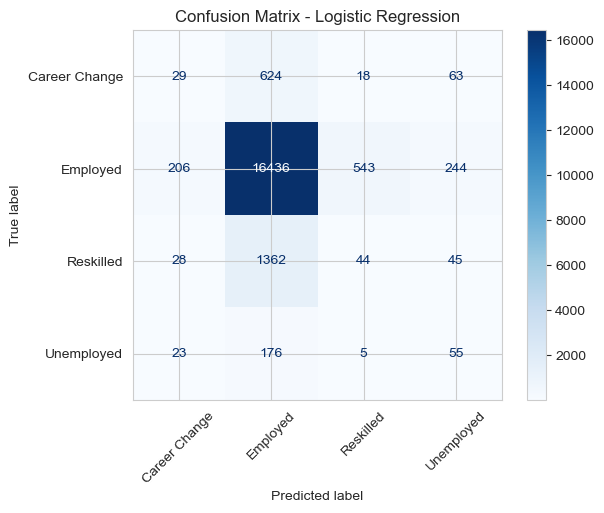

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = LogisticRegression(max_iter=500, random_state=42)

best_model.fit(X_train_smote_scaled, y_train_smote)

y_pred = best_model.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=label_encoder.classes_,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [53]:
# Hyperparameter Tuning - Random Forest

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=15,
    scoring="f1_weighted",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_train, y_train)

print("="*60)
print("Best Parameters")
print(rf_search.best_params_)

print("="*60)
print("Best F1 Score")
print(rf_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best F1 Score
0.817987496524707


In [54]:
# Evaluate Best Random Forest

best_rf = rf_search.best_estimator_

y_pred = best_rf.predict(X_test)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

               precision    recall  f1-score   support

Career Change       0.00      0.00      0.00       734
     Employed       0.88      1.00      0.93     17429
    Reskilled       0.00      0.00      0.00      1479
   Unemployed       0.00      0.00      0.00       259

     accuracy                           0.88     19901
    macro avg       0.22      0.25      0.23     19901
 weighted avg       0.77      0.88      0.82     19901



# Save Best Model

In [55]:
import joblib

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Models Saved Successfully!")

Models Saved Successfully!


In [56]:
import joblib

feature_columns = X_train.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

print("Saved Successfully!")

Saved Successfully!
